## Eigenvalue sensitivities of shear-flow tearing: running exponents, marginal Newton, non-normality

**Rung 1b (science) of `plans/AUTODIFF_PLAN.md`.** Rungs 1a and 1b-ref (`tearing-eigen.ipynb`,
`tearing-shear-eigen.ipynb`) validated the eigen-harness `taranis/stability.py` -- the exact Jacobian
$J=L+N'(x_0)$ of the solver's own discrete right-hand side -- against exact tearing theory and
against Alfred's Julia eigencode. This notebook uses the harness's **first-order perturbation
theory** instead of differencing eigenvalues. For a simple eigenvalue $\lambda$ of $J$ with right
vector $v$ and left vector $w$ ($J^Hw=\bar\lambda w$), and any parameter $s$ that enters through the
equilibrium $x_0(s)$,
$$\frac{d\lambda}{ds}=\frac{w^H\,(\partial J/\partial s)\,v}{w^Hv},\qquad
\frac{\partial J}{\partial s}v=\frac{d}{d\epsilon}\Big[N'(x_0+\epsilon\,\partial_sx_0)\,v\Big]_{\epsilon=0},$$
the second factor a **forward-over-forward** `jax.jvp` of `construct_rhs` (`stability.dj_operator`),
$w$ from shift-invert on $J^H$ (`stability.left_eigenvector`, the adjoint by `vjp`), and the formula
with its refusal criteria in `stability.eigenvalue_sensitivity` (residuals $\le10^{-8}$, $w^Hv$ not
at round-off, and $\kappa\,\delta/\mathrm{gap}\le10^{-3}$, $\kappa=\|w\|\|v\|/|w^Hv|$ the eigenvalue
condition number, $\delta$ the pair's backward error). **No derivative below is a difference of
eigenvalues**, except in the FD gates that check the formula.

**Setup** (exactly rung 1b-ref): `dims=2`, $\nu=0$ (`diss=(0, η)`), `hyper=1`, $S=1/\eta$,
$\Psi_0=\mathrm{sech}^2x$ (+ its two nearest periodic images), $\Phi_0=\alpha\Psi_0$, $L_x=\max(15/k,20)$,
the $k_y=k$ block, fp64. Two parameters enter through $x_0$:

* **$\alpha$**: $\partial x_0/\partial\alpha=(\Psi_0,0)$ in $(\phi,\psi)$. Since $N$ is quadratic,
  $J(\alpha)=J(0)+\alpha\,\partial_\alpha J$ **exactly** (checked in §1).
* **the sheet width $a$ at fixed $k$ and $\eta$** (§5): the family keeps the *field* amplitude,
  $B_y(x;a)=f(x/a)$, i.e. $\Psi_0(x;a)=a\,\hat\Psi_0(x/a)$. The outer equation
  $\psi''=(k^2+f''/(a^2f))\psi$ is then a function of $x/a$ and $ka$ only, so **$\Delta'a$ depends on
  $ka$ alone**: $\Delta'a=2(5-k^2a^2)(k^2a^2+3)/(k^2a^2\sqrt{k^2a^2+4})$ for sech$^2$ (zero at
  $ka=\sqrt5$) and $2(1/ka-ka)$ for tanh (zero at $ka=1$). The tangent is analytic,
  $\partial_a[a\,\mathrm{sech}^2(x/a)]=\mathrm{sech}^2u\,(1+2u\tanh u)$, $u=x/a$ (tanh pair:
  $\partial_a\tanh((x-x_s)/a)=-u\,\mathrm{sech}^2u/a$, integrated by FFT). $\eta$ is held fixed, so the
  sheet's own Lundquist number $a/\eta$ moves with $a$; the ideal marginal point does not depend on it.

**The paper's asymptotes** (Mallet, Eriksson, Swisdak & Juno, JPP 91, E146 (2025); the scalings
in the Julia code's `goodguess`): constant-$\psi$ $\gamma\propto S^{-1/2}(1-\alpha^2)^{1/2}k^{-1/2}$,
nonconstant-$\psi$ $\gamma\propto(1-\alpha^2)^{2/3}S^{-1/3}k^{2/3}$, crossing at
$K_{tr}\propto S^{-1/7}(1-\alpha^2)^{-1/7}$, so the maximum grows like $(1-\alpha^2)^{4/7}S^{-3/7}$. The
**running exponent**
$$p(\alpha)=\frac{d\ln\gamma}{d\ln(1-\alpha^2)}=\frac{d\gamma}{d\alpha}\,\frac{1-\alpha^2}{-2\alpha\gamma}$$
should approach 1/2, 2/3 and 4/7 respectively. Those scalings assume a shear-modified inner layer
thin compared with the sheet, $\delta_{in}/a=(\alpha/(1-\alpha^2))^{1/3}(kaS)^{-1/3}\ll1$ (paper eq.
5.15), i.e. an asymptotic window $1/(kaS)\ll1-\alpha^2\ll1$ that only opens with $S$. On the
**maximum-growth ridge** the envelope theorem gives $d\gamma_{max}/d\alpha=\partial_\alpha\gamma$ at
$k_{max}$ (because $\partial_k\gamma=0$ there), so the ridge exponent needs no $k$-derivative -- rung 2's
overrides seam is not required.

**Solver, per point** (all matrix-free on the ky block, `tearing_sensitivity_run.py`): right pair by
`shift_invert(k=1)` with rung 1a's band-LU-preconditioned GMRES (for $\alpha$ the bands of $J(0)$ and
$\partial_\alpha J$ are probed once per $(S,ka,n_x)$ and combined); left pair by `left_eigenvector` at the
same shift, preconditioned by the *adjoint* solve of the same LU; `dj_operator` along the tangent;
`eigenvalue_sensitivity`. **Its `spectrum` (the gap) comes from a dense spectrum of the same block on a
coarse seed grid** ($n_x=1024$): `shift_invert` with $k\ge2$ does not converge here -- ARPACK, 300
restarts, 1 of 2 converged at $S=10^4$, $ka=0.5$, $\alpha=0.8$, $n_x=4096$ -- because the next-nearest
eigenvalues are the $\nu=0$ **null cluster** at $\lambda=0$ ($|\mathrm{Re}|\sim10^{-16}$,
$|\mathrm{Im}|\le10^{-10}$ in `eig_dense` at every $n_x$ tried), a near-degenerate cluster no Krylov
method splits. The dense spectrum certifies that that cluster is the nearest competitor, $|\lambda|$ away,
and the fine-grid $\lambda$ plus the coarse grid's *other* eigenvalues is what is passed (gap
$\simeq|\lambda|$). Every point is solved at $n_x^{hi}$ (1b-ref's rung already within $10^{-7}$ in
$\gamma$) and at $n_x^{hi}/2$ as its grid check -- except the $S=10^5$, $ka=0.1$ family
(10-15 min per point), which has the $n_x^{hi}/2$ solve at $\alpha=0.1$ only, so its plateau is not grid-checked.

**Data.** `tearing_sensitivity_run.py` (resumable `make_data()`, one cache file per solve under
`examples/data/tearing-sensitivity/`, gitignored; phases `fd const const2 nonconst ridge marginal
marginal_tanh`). The first execution computes (cost cell at the end); every later one only reads.

In [1]:
# fp64 must be selected before taranis/jax import (TARANIS_PRECISION is read at import)
import os
os.environ["TARANIS_PRECISION"] = "64"
import glob
import time
import numpy as np
import matplotlib.pyplot as plt
import tearing_eigen_run as T
import tearing_sensitivity_run as U

t0 = time.time()


def read_all():
    fam = {}
    for S in U.S_EXP:
        fam[(S, U.KA_NONCONST)] = U.family_results(S, U.KA_NONCONST)
    for S in U.S_EXP_CONST:
        for ka in (U.KA_CONST, U.KA_CONST2):
            fam[(S, ka)] = U.family_results(S, ka)
    ridge = {S: U.ridge_results(S) for S in U.S_RIDGE}
    marg = {(case, S, sec): U.marginal_results(S, case, sec)
            for S in U.MARG_S for case, sec in (("sech2", 0), ("tanhpair", 1), ("tanhpair", -1))}
    return fam, U.fd_results(), ridge, marg


if not glob.glob(os.path.join(U.DATA_ROOT, "solves", "*.npz")):
    U.make_data(log=lambda *a: None)   # fresh checkout: compute (resumable; ~7 h of solves)
FAM, FD, RIDGE, MARG = read_all()     # read-back only: points never computed are gaps
print(f"data ready ({time.time() - t0:.0f} s this call)")

field variables are using 64bit precision.
data ready (2 s this call)


### 1. The sensitivity against finite differences, and grid convergence

**FD gate** (plan acceptance): $d\gamma/d\alpha$ from $w^H\partial_\alpha J\,v/w^Hv$ against the central
difference $[\lambda(\alpha+h)-\lambda(\alpha-h)]/2h$ of eigenvalues solved by the same preconditioned
shift-invert at the same $n_x$ (the discrete derivative is what the formula computes), at four points
spanning both regimes, $S=10^4$-$10^5$ and $\alpha$ up to 0.99. Near $\alpha=1$ the step must stay well inside
$1-\alpha$: at $\alpha=0.99$, $h=0.01$ lands on $\alpha=1$ (a first attempt did, and missed by 98 %),
so $h=3\times10^{-3},10^{-3},3\times10^{-4}$ there.

In [2]:
# FD gate: central differences of eigenvalues at alpha +- h (same nx, same preconditioned
# shift-invert) against the sensitivity w^H dJ v / w^H v
print("  S      ka   alpha   nx    |  dgamma/dalpha (sens.)   |   h       FD - sens     rel.     | order")
FDROWS = []
for (S, ka, al), (rec, rows) in FD.items():
    d = complex(rec["dlam"]).real
    hs = np.array([r[0] for r in rows]); es = np.array([r[2] for r in rows])
    order = np.polyfit(np.log(hs), np.log(es), 1)[0]
    FDROWS.append((S, ka, al, order, es[-1]/abs(d)))
    for i, (h, fd, e) in enumerate(rows):
        head = f"  {S:.0e}  {ka:3.1f}  {al:5.3f}  {int(rec['nx']):5d}  |  {d:+.12e}  |" if i == 0 else \
            " "*52 + "|"
        print(f"{head}  {h:6.0e}  {(fd - rec['dlam']).real:+.3e}  {e/abs(d):.1e}  |" +
              (f"  {order:.3f}" if i == len(rows) - 1 else ""))

  S      ka   alpha   nx    |  dgamma/dalpha (sens.)   |   h       FD - sens     rel.     | order
  1e+04  0.1  0.800   4096  |  -2.204910291208e-02  |   1e-02  -4.920e-06  2.2e-04  |
                                                    |   3e-03  -4.425e-07  2.0e-05  |
                                                    |   1e-03  -4.917e-08  2.2e-06  |  2.000
  1e+04  1.0  0.950   2048  |  -8.203198790854e-02  |   1e-02  -4.473e-04  5.5e-03  |
                                                    |   3e-03  -3.967e-05  4.8e-04  |
                                                    |   1e-03  -4.402e-06  5.4e-05  |  2.007
  1e+05  0.1  0.990   8192  |  -3.389999252569e-02  |   3e-03  -2.770e-05  8.2e-04  |
                                                    |   1e-03  -4.450e-06  1.3e-04  |
                                                    |   3e-04  -4.126e-07  1.2e-05  |  1.829
  1e+05  1.0  0.600   4096  |  -2.908489862447e-03  |   1e-02  -9.686e-07  3.3e-04  |
                     

In [3]:
# J(alpha) = J(0) + alpha dJ exactly (N quadratic, Phi0 = alpha Psi0): the identity the band
# preconditioner uses, checked on a small block through the harness's own matrices
import taranis as jr
from taranis import stability as st
p = U.make_params(1e4, 0.5, 512, 30.0); kg = jr.setup_kgrids(p)
J = {al: st.ky_block_matrix(U.equilibrium(p, al)[0], kg, p, 1)[0] for al in (0.0, 0.8)}
dJ, _ = st.dj_matrix(*U.equilibrium(p, 0.3), kg, p, iky=1)      # dJ at another alpha: constant
err = np.abs(J[0.8] - J[0.0] - 0.8*dJ).max()/np.abs(J[0.8]).max()
print(f"max |J(0.8) - J(0) - 0.8 dJ(0.3)| / max|J| = {err:.1e}")

max |J(0.8) - J(0) - 0.8 dJ(0.3)| / max|J| = 7.7e-14


In [4]:
# grid convergence of every sensitivity: nx_hi (1b-ref's rung already within 1e-7 in gamma) vs
# nx_hi/2
print("  S      ka   | points | alpha >= 0.3: max rel. change gamma  dgamma/dalpha   p (abs)   "
      "kappa (rel) | alpha = 0.1: |d dgamma|/gamma | max rel_err  max residual")
CONV = {}
for (S, ka), f in sorted(FAM.items()):
    lo, hi = f.get(2, {}), f[1]
    common = [a for a in hi if a in lo and a >= 0.3]
    if not common:
        continue
    a01 = abs(complex(hi[0.1]["dlam"]) - complex(lo[0.1]["dlam"]))/abs(complex(hi[0.1]["lam"])) \
        if 0.1 in hi and 0.1 in lo else np.nan
    g = max(abs(complex(hi[a]["lam"]) / complex(lo[a]["lam"]) - 1) for a in common)
    d = max(abs(complex(hi[a]["dlam"]) / complex(lo[a]["dlam"]) - 1) for a in common)
    pp = max(abs(U.exponent(hi[a]) - U.exponent(lo[a])) for a in common)
    kk = max(abs(float(hi[a]["kappa"]) / float(lo[a]["kappa"]) - 1) for a in common)
    re = max(float(hi[a]["rel_err"]) for a in hi)
    rs = max(max(float(hi[a]["res_r"]), float(hi[a]["res_l"])) for a in hi)
    CONV[(S, ka)] = (g, d, pp, kk)
    print(f"  {S:.0e}  {ka:3.1f}  |  {len(hi):3d}   |          {g:.1e}             {d:.1e}        "
          f"{pp:.1e}    {kk:.1e}     |        {a01:.1e}              |  {re:.1e}      {rs:.1e}")

  S      ka   | points | alpha >= 0.3: max rel. change gamma  dgamma/dalpha   p (abs)   kappa (rel) | alpha = 0.1: |d dgamma|/gamma | max rel_err  max residual
  1e+03  0.1  |   15   |          2.1e-04             2.0e-03        9.2e-04    1.4e+00     |        3.2e-04              |  3.5e-11      4.9e-13
  1e+03  1.0  |   15   |          6.7e-10             4.0e-09        1.9e-10    1.9e+00     |        6.3e-12              |  2.6e-05      3.1e-13
  1e+03  1.5  |   15   |          2.3e-09             7.8e-08        6.9e-10    2.6e+00     |        4.9e-11              |  1.9e-04      6.5e-13
  1e+04  0.1  |   15   |          1.8e-04             1.9e-03        1.0e-03    2.1e+00     |        3.8e-04              |  1.4e-07      1.1e-12
  1e+04  1.0  |   15   |          7.0e-07             2.3e-04        2.2e-05    2.9e+00     |        1.4e-04              |  5.3e-08      2.6e-15
  1e+04  1.5  |   15   |          5.1e-05             1.6e-02        1.5e-03    2.9e+00     |        1.2e-02  

**Result.** At every point the difference falls as $h^2$ -- fitted orders 2.000, 2.007 and 2.002, and 1.83 at $\alpha=0.99$ (where the largest step is
$0.3(1-\alpha)$; its last two steps give 1.97) -- down to $2\times10^{-6}$-$5\times10^{-5}$ relative at the
smallest $h$: the sensitivity formula, the left eigenvector and the
forward-over-forward $\partial_\alpha J$ are right to the accuracy FD can check. $J$ is affine in $\alpha$
to $8\times10^{-14}$ (the identity the preconditioner relies on).

**Grid convergence.** The table compares $n_x^{hi}$ with the *coarser* $n_x^{hi}/2$, so it bounds the
coarse level's error: for $\alpha\ge0.3$, $\gamma$ moves by $\le2\times10^{-4}$ and $d\gamma/d\alpha$ by
$\le2\times10^{-2}$ relative (the worst are $ka=1.5$, which borrows $ka=1$'s grid, and $ka=0.1$ at
$n_x=1024$-2048), $p$ by $\le6\times10^{-3}$ -- invisible on the figures. At $n_x^{hi}$ itself the
$\kappa$-vs-$n_x$ study of §4 shows $d\gamma/d\alpha$ converged to $\sim10^{-9}$ relative from $n_x=512$-2048
on. At $\alpha=0.1$, $d\gamma/d\alpha\propto\alpha$ is itself small, so $p$ (a ratio of small numbers: the first column of the table below,
$-6.3$ to $+0.61$) carries that absolute error and is not used for any conclusion. **$\kappa$ is
the exception**: it changes by up to $\times2.9$ between the two levels; §4 shows it needs a much finer
grid than the eigenvalue. **The table has no $S=10^5$, $ka=0.1$ row**: that family was solved at
$n_x^{hi}=8192$ only (its one $n_x^{hi}/2$ solve is at $\alpha=0.1$), so its exponents -- including the 0.646
plateau of §2 -- rest on $\gamma$ being converged there (1b-ref's ladders) with no grid check of $d\gamma/d\alpha$ itself.

### 2. Running exponents at fixed $k$

$p(\alpha)=d\ln\gamma/d\ln(1-\alpha^2)$ from one sensitivity per point, on a grid in $\ln(1-\alpha^2)$ down
to $1-\alpha^2=2\times10^{-3}$ ($2\times10^{-4}$ at $S\ge10^5$). Nonconstant-$\psi$: $ka=0.1$ ($\Delta'\delta\gg1$ at
every $S$ here, and $ka<K_{tr}$). Constant-$\psi$: $ka=1$ and $ka=1.5$ ($ka/K_{tr}\approx5$ and 8 at $S=10^5$,
$\alpha=0$). Gaps in a row are points the harness refused (§4); $S=10^6$, $ka=1$, $\alpha=0.9999$, whose right pair failed
`shift_invert`'s own residual gate ($1.5\times10^{-9}$ against $10^{-9}$); $S=10^6$, $ka=1.5$, $\alpha\ge0.9995$, never
computed; and, for $ka=0.1$ at $S=10^5$
(~10 min per point at $n_x=8192$, $L_x=150$), a subset of six $\alpha$.

In [5]:
def curve(S, ka):
    f = FAM[(S, ka)][1]
    al = np.array(sorted(f))
    return al, np.array([U.exponent(f[a]) for a in al]), \
        np.array([complex(f[a]["lam"]).real for a in al]), np.array([float(f[a]["kappa"]) for a in al])


print("running exponent p = d ln gamma / d ln(1 - alpha^2) at fixed k (sensitivity, nx_hi)")
for ka in (U.KA_NONCONST, U.KA_CONST, U.KA_CONST2):
    Ss = U.S_EXP if ka == U.KA_NONCONST else U.S_EXP_CONST
    al = np.array(U.ALPHAS + U.ALPHAS_TAIL)
    print(f"\n  ka = {ka}:   1 - alpha^2 = " + " ".join(f"{1 - a*a:8.1e}" for a in al))
    for S in Ss:
        a_, p_, _, _ = curve(S, ka)
        row = {a: v for a, v in zip(a_, p_)}
        print(f"  S = {S:.0e}             " + " ".join(f"{row[a]:8.4f}" if a in row else " "*8 for a in al))

running exponent p = d ln gamma / d ln(1 - alpha^2) at fixed k (sensitivity, nx_hi)

  ka = 0.1:   1 - alpha^2 =  9.9e-01  9.1e-01  8.0e-01  6.4e-01  5.1e-01  3.6e-01  2.4e-01  1.5e-01  9.8e-02  5.9e-02  4.0e-02  2.0e-02  1.0e-02  4.0e-03  2.0e-03  1.0e-03  4.0e-04  2.0e-04
  S = 1e+03               0.5104   0.5105   0.5075   0.4957   0.4757   0.4314   0.3646   0.2733   0.1860   0.1115   0.0714   0.0328   0.0153   0.0058   0.0029                           
  S = 1e+04               0.5971   0.6015   0.6064   0.6106   0.6112   0.6054   0.5887   0.5513   0.4859   0.3642   0.2232  -0.0153  -0.0759  -0.0433  -0.0231                           
  S = 1e+05               0.6118                     0.6326            0.6438            0.6458            0.6301            0.5590                                                      

  ka = 1.0:   1 - alpha^2 =  9.9e-01  9.1e-01  8.0e-01  6.4e-01  5.1e-01  3.6e-01  2.4e-01  1.5e-01  9.8e-02  5.9e-02  4.0e-02  2.0e-02  1.0e-02  4.0e-03  2.0e-03  1.

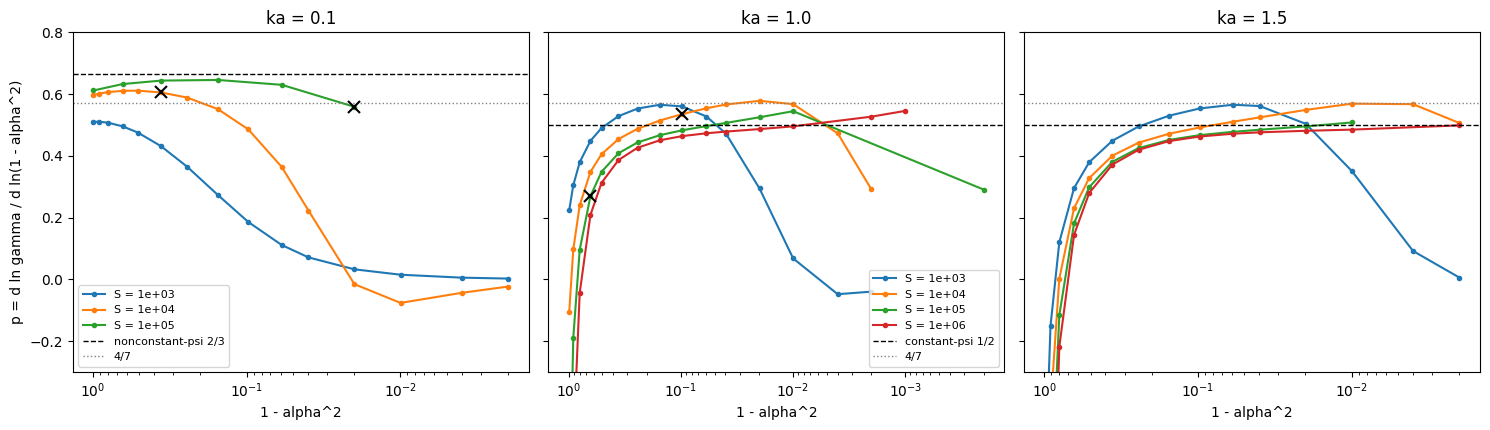

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
for ax, ka, ref, lab in ((axs[0], U.KA_NONCONST, 2/3, "nonconstant-psi 2/3"),
                         (axs[1], U.KA_CONST, 1/2, "constant-psi 1/2"),
                         (axs[2], U.KA_CONST2, 1/2, "constant-psi 1/2")):
    Ss = U.S_EXP if ka == U.KA_NONCONST else U.S_EXP_CONST
    for j, S in enumerate(Ss):
        al, p_, _, _ = curve(S, ka)
        ax.semilogx(1 - al**2, p_, "o-", ms=3, color=f"C{j}", label=f"S = {S:.0e}")
    ax.axhline(ref, color="k", ls="--", lw=1, label=lab)
    ax.axhline(4/7, color="gray", ls=":", lw=1, label="4/7")
    for (S_, ka_, al_), (rec, rows) in FD.items():       # FD-gated points
        if ka_ == ka:
            ax.plot(1 - al_**2, (rows[-1][1].real)*(1 - al_**2)/(-2*al_*complex(rec["lam"]).real),
                    "kx", ms=9, mew=1.5)
    ax.invert_xaxis(); ax.set_xlabel("1 - alpha^2"); ax.set_title(f"ka = {ka}")
    ax.set_ylim(-0.3, 0.8)
axs[0].set_ylabel("p = d ln gamma / d ln(1 - alpha^2)")
axs[0].legend(fontsize=8); axs[1].legend(fontsize=8)
plt.tight_layout()

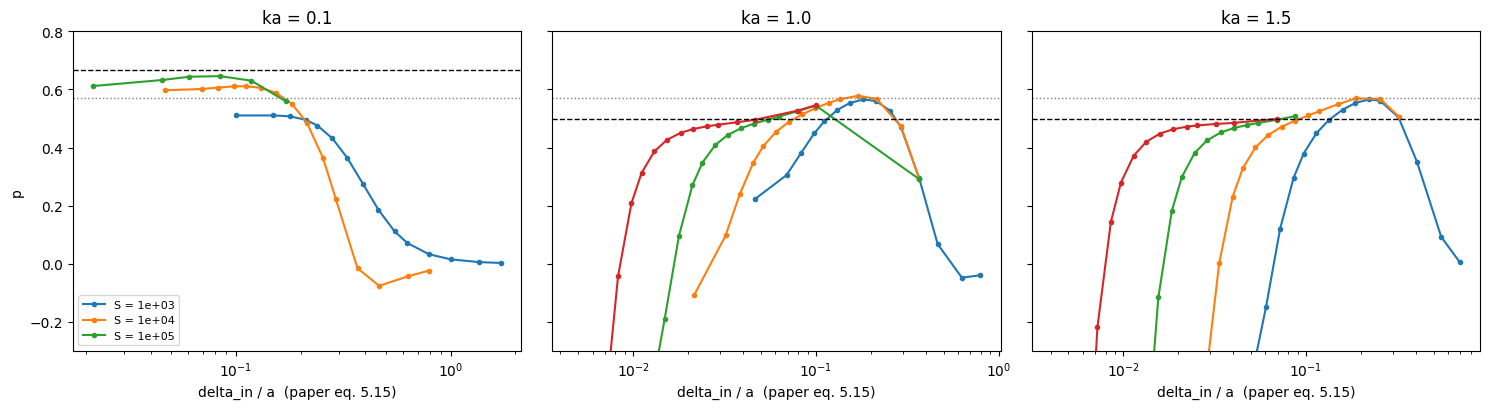

In [7]:
# the same exponents against the paper's shear-layer width delta_in/a = (alpha/(1-alpha^2))^(1/3)
# (kaS)^(-1/3) (eq. 5.15): the asymptotic scalings need delta_in << a
fig, axs = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, ka, ref in ((axs[0], U.KA_NONCONST, 2/3), (axs[1], U.KA_CONST, 1/2), (axs[2], U.KA_CONST2, 1/2)):
    Ss = U.S_EXP if ka == U.KA_NONCONST else U.S_EXP_CONST
    for j, S in enumerate(Ss):
        al, p_, _, _ = curve(S, ka)
        d = (al/(1 - al**2))**(1/3)*(ka*S)**(-1/3)
        ax.semilogx(d, p_, "o-", ms=3, color=f"C{j}", label=f"S = {S:.0e}")
    ax.axhline(ref, color="k", ls="--", lw=1); ax.axhline(4/7, color="gray", ls=":", lw=1)
    ax.set_xlabel("delta_in / a  (paper eq. 5.15)"); ax.set_title(f"ka = {ka}"); ax.set_ylim(-0.3, 0.8)
axs[0].set_ylabel("p"); axs[0].legend(fontsize=8)
plt.tight_layout()

**Result: the exponents are smooth curves, and they reach their asymptotes only inside a window that
opens with $S$.**

* **Constant-$\psi$ ($ka=1$, 1.5).** At fixed $1-\alpha^2$ the exponent *falls* with $S$ toward 1/2 from
  above (at $1-\alpha^2=0.1$: $ka=1$ gives 0.560, 0.535, 0.483, 0.464 at $S=10^3$-$10^6$), and the range of $\alpha$ over which it sits near 1/2
  widens with $S$: at $S=10^6$ it is 0.464-0.496 over $1-\alpha^2=0.1$-0.01 ($ka=1$). The constant-$\psi$
  exponent **1/2 is reached** -- to within 1-2 % at $S=10^6$ -- and approached from below as
  $\alpha\to1$ inside the window. At $S=10^3$ the curves peak at $p=0.566$ ($ka=1$ and 1.5) and
  collapse to $p\approx0$ (slightly negative at $ka=1$) by $\alpha=0.999$; at $S=10^4$ they peak at 0.578 / 0.569
  and are falling at $\alpha=0.999$ (0.29 / 0.51). At $S=10^5$ and $10^6$ the refusals (§4) cut the curves while they
  still rise (0.545 / 0.508 at $S=10^5$, 0.546 / 0.499 at $S=10^6$, $ka=1$ / 1.5): no peak is resolved there, and the
  one point past the gap, $S=10^5$, $ka=1$, $\alpha=0.9999$, is down to 0.29.
* **Nonconstant-$\psi$ ($ka=0.1$).** A plateau that rises with $S$ -- max 0.511, 0.611, 0.646 at $S=10^3,10^4,10^5$ --
  still **below 2/3** at $S=10^5$ (0.646 vs 0.667; no $n_x$ grid check at $S=10^5$, §1); then a collapse toward 0 at large $\alpha$, earlier in
  $1-\alpha^2$ the smaller $S$ is.
* **Small $\alpha$** is not in the asymptotic regime at all (the flow does not yet set the layer): $p$ is
  small or negative there and strongly $S$-dependent -- $\gamma$ even *rises* with weak flow (negative $p$) at $ka=1$,
  $S\ge10^4$ and at $ka=1.5$ already at $S=10^3$ ($p=-0.67$ at $\alpha=0.1$), the effect 1b-ref noted at $ka=1$ ("weak shear slightly raises $\gamma$").

**What closes the window** is the width of the shear-modified layer: plotted against the paper's
$\delta_{in}/a=(\alpha/(1-\alpha^2))^{1/3}(kaS)^{-1/3}$ (next figure), the constant-$\psi$ curves that resolve a peak ($S=10^3$, $10^4$) peak at
$\delta_{in}/a\approx0.17$-0.22, and at $ka=1$ are down to $p=0.29$-0.30 at $\delta_{in}/a=0.37$ -- at $S=10^3$, $10^4$ *and* at the one
$S=10^5$ point past the refusal gap; at $S=10^6$ the curves end at $\delta_{in}/a\le0.1$, before any peak. The nonconstant-$\psi$
curves leave their plateau at $\delta_{in}/a\approx0.1$-0.2. The asymptotic scalings assume
$\delta_{in}\ll a$; the data say that "$\ll$" means $\lesssim0.1$. The left edge of the window (the flow
dominating the layer) moves to smaller $\delta_{in}/a$ as $S$ grows, which is why the plateau near 1/2
only emerges at $S\ge10^5$-$10^6$.

### 3. The maximum-growth ridge: 4/7, and 1b-ref's $\gamma_{max}(\alpha)/\gamma_{max}(0)$

At each $\alpha$, five $ka$ on a fixed geometric grid around the predicted $k_{max}$; a quadratic in $\ln k$
through $\gamma$ gives $k_{max}$, $\gamma_{max}$, and one through $\partial_\alpha\gamma$ evaluated at
$k_{max}$ gives $d\gamma_{max}/d\alpha$ (envelope theorem). The same fits give $dk_{max}/d\alpha=-\gamma_{k\alpha}/
\gamma_{kk}$ with $\gamma_{k\alpha}$ the $\ln k$-slope of the $\partial_\alpha\gamma$ fit -- $k_{max}(\alpha)$'s own
running exponent, against the paper's $-1/7$, also without any $k$-derivative of the operator. Fits whose
maximum leaves the sampled range are flagged (`inside`) and not used.

In [8]:
RF = {S: {al: U.ridge_fit(rows) for al, rows in RIDGE[S].items() if len(rows) == 5}
      for S in U.S_RIDGE}
print("ridge: quadratic-in-ln k fits through 5 ka around k_max(alpha); p on the ridge = the fixed-k "
      "exponent at k_max (envelope theorem)")
print("   S     alpha  1-a^2   | k_max    (+-)     inside | gamma_max       | p_ridge   | "
      "d ln kmax/d ln(1-a^2)")
for S in U.S_RIDGE:
    for al, r in RF[S].items():
        print(f"  {S:.0e}  {al:6.4f} {1-al*al:7.1e} | {r['kmax']:.4f}  {r['kmax_err']:.0e}  "
              f"{str(r['inside']):5s}  | {r['gmax']:.6e}  | {r['p']:.4f}    | {r['pk']:+.4f}")

ridge: quadratic-in-ln k fits through 5 ka around k_max(alpha); p on the ridge = the fixed-k exponent at k_max (envelope theorem)
   S     alpha  1-a^2   | k_max    (+-)     inside | gamma_max       | p_ridge   | d ln kmax/d ln(1-a^2)
  1e+04  0.1000 9.9e-01 | 0.4613  5e-03  True   | 3.114135e-02  | 0.4837    | -0.2669
  1e+04  0.3000 9.1e-01 | 0.4714  6e-03  True   | 2.987953e-02  | 0.4976    | -0.2472
  1e+04  0.6000 6.4e-01 | 0.5092  3e-03  True   | 2.493785e-02  | 0.5327    | -0.1812
  1e+04  0.8000 3.6e-01 | 0.5604  6e-03  True   | 1.817984e-02  | 0.5621    | -0.1584
  1e+04  0.9200 1.5e-01 | 0.6287  7e-03  True   | 1.117366e-02  | 0.5820    | -0.1227
  1e+04  0.9500 9.8e-02 | 0.6631  6e-03  True   | 8.576523e-03  | 0.5875    | -0.0960
  1e+04  0.9800 4.0e-02 | 0.7165  4e-03  True   | 5.042141e-03  | 0.5913    | -0.0371
  1e+04  0.9900 2.0e-02 | 0.7089  5e-03  True   | 3.368667e-03  | 0.5752    | +0.0956
  1e+04  0.9950 1.0e-02 | 0.6583  5e-02  False  | 2.303357e-03  | 0.4934    |

In [9]:
# integrate the ridge exponent in ln u (u = 1 - alpha^2) from alpha = 0.1, and compare the
# resulting gamma_max ratios with the fitted gamma_max themselves and with 1b-ref's
# gamma_max(alpha)/gamma_max(0) (its 10-ka peak fits; alpha = 0 from its table)
tab = U.shear_tables()
kas_ref = sorted({k for k, _ in tab})
print("   S     alpha | gmax/gmax(0.1): integrated p   direct fit   rel.diff | "
      "gmax/gmax(0): this nb   1b-ref    (1-a^2)^(4/7)")
RINT = {}
for S in U.S_RIDGE:
    al = np.array(sorted(a for a in RF[S] if RF[S][a]["inside"])); u = 1 - al**2
    p_ = np.array([RF[S][a]["p"] for a in al]); gm = np.array([RF[S][a]["gmax"] for a in al])
    lu = np.log(u)
    integ = np.concatenate([[0.0], np.cumsum(0.5*(p_[1:] + p_[:-1])*np.diff(lu))])
    g0 = T.peak_fit(kas_ref, [complex(tab[(k, 0.0)][S]["value"]).real for k in kas_ref])[1]
    # alpha = 0 -> 0.1 by the same integral (p flat to <1e-2 there)
    g01 = np.exp(p_[0]*lu[0])
    RINT[S] = (al, np.exp(integ), gm/gm[0], gm/g0)
    for i, a in enumerate(al):
        gref = None
        if a in (0.3, 0.6, 0.8, 0.95):
            gref = T.peak_fit(kas_ref, [complex(tab[(k, a)][S]["value"]).real for k in kas_ref])[1]/g0
        print(f"  {S:.0e}  {a:6.4f} |   {np.exp(integ[i]):.5f}             {gm[i]/gm[0]:.5f}     "
              f"{np.exp(integ[i])/(gm[i]/gm[0]) - 1:+.1e} |   {gm[i]/g0:.4f}  "
              f"(int: {g01*np.exp(integ[i]):.4f})  " + (f"{gref:.4f}" if gref else "  --  ") +
              f"     {u[i]**(4/7):.4f}")

   S     alpha | gmax/gmax(0.1): integrated p   direct fit   rel.diff | gmax/gmax(0): this nb   1b-ref    (1-a^2)^(4/7)
  1e+04  0.1000 |   1.00000             1.00000     +0.0e+00 |   0.9945  (int: 0.9952)    --       0.9943
  1e+04  0.3000 |   0.95950             0.95948     +2.2e-05 |   0.9542  (int: 0.9548)  0.9550     0.9475
  1e+04  0.6000 |   0.80039             0.80080     -5.0e-04 |   0.7964  (int: 0.7965)  0.7962     0.7749
  1e+04  0.8000 |   0.58416             0.58378     +6.4e-04 |   0.5806  (int: 0.5813)  0.5811     0.5578
  1e+04  0.9200 |   0.35886             0.35880     +1.5e-04 |   0.3568  (int: 0.3571)    --       0.3428
  1e+04  0.9500 |   0.27511             0.27541     -1.1e-03 |   0.2739  (int: 0.2738)  0.2738     0.2644
  1e+04  0.9800 |   0.16176             0.16191     -9.3e-04 |   0.1610  (int: 0.1610)    --       0.1580
  1e+04  0.9900 |   0.10829             0.10817     +1.0e-03 |   0.1076  (int: 0.1078)    --       0.1066
  1e+05  0.1000 |   1.00000     

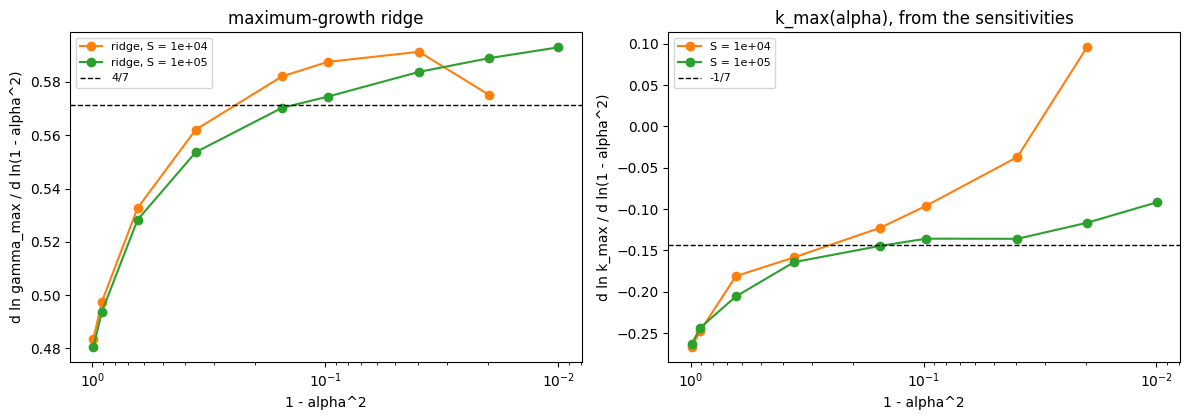

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.3))
for j, S in enumerate(U.S_RIDGE):
    al = np.array(sorted(a for a in RF[S] if RF[S][a]["inside"])); u = 1 - al**2
    axs[0].semilogx(u, [RF[S][a]["p"] for a in al], "o-", color=f"C{j+1}", label=f"ridge, S = {S:.0e}")
    axs[1].semilogx(u, [RF[S][a]["pk"] for a in al], "o-", color=f"C{j+1}", label=f"S = {S:.0e}")
axs[0].axhline(4/7, color="k", ls="--", lw=1, label="4/7")
axs[1].axhline(-1/7, color="k", ls="--", lw=1, label="-1/7")
for ax in axs:
    ax.invert_xaxis(); ax.set_xlabel("1 - alpha^2"); ax.legend(fontsize=8)
axs[0].set_ylabel("d ln gamma_max / d ln(1 - alpha^2)")
axs[1].set_ylabel("d ln k_max / d ln(1 - alpha^2)")
axs[0].set_title("maximum-growth ridge"); axs[1].set_title("k_max(alpha), from the sensitivities")
plt.tight_layout()

**Result: the ridge exponent crosses 4/7 and overshoots it slightly.** $p_{ridge}$ rises from 0.48
($\alpha=0.1$) through $4/7=0.571$ at $1-\alpha^2\approx0.25$ ($S=10^4$) / 0.14 ($S=10^5$) to a maximum 0.591 ($S=10^4$, $1-\alpha^2=0.04$) / 0.593 ($S=10^5$, $1-\alpha^2=0.01$, still rising slowly), and at fixed
$1-\alpha^2$ it *decreases* with $S$ (by $\approx0.01$ per decade at $1-\alpha^2=0.04$-0.4), i.e. it is
consistent with 4/7 approached from above as $S\to\infty$, not yet reached at $S=10^5$. The
$k_{max}$ exponent runs from $-0.26$ to $-0.09$ ($S=10^5$, $1-\alpha^2=0.01$), passing through $-1/7$ at
$1-\alpha^2\approx$ 0.14 at $S=10^5$, where it then stays at $-0.136$ to $-0.145$ down to $1-\alpha^2=0.04$ ($-1/7$ within 5 % over a factor 4 in $1-\alpha^2$), and $\approx0.25$ at $S=10^4$ -- and at $S=10^4$ it turns positive where the ridge fits leave their range
($k_{max}$ falls back at large $\alpha$, the 1b-ref $S=10^3$, $\alpha=0.95$ effect one decade later).

**Reconciling with 1b-ref.** Integrating $p_{ridge}$ in $\ln(1-\alpha^2)$ reproduces the directly fitted
$\gamma_{max}$ ratios to $\le2.2\times10^{-3}$ (a consistency check of the sensitivities across 5 $ka$ and 8-9
$\alpha$), and 1b-ref's independent ten-$ka$ peak fits of $\gamma_{max}(\alpha)/\gamma_{max}(0)$ to
$\le3\times10^{-3}$: at $\alpha=0.95$ both give 0.274 ($S=10^4$) and 0.280 ($S=10^5$). The secant exponent
$\ln(\gamma_{max}/\gamma_{max,0})/\ln(1-\alpha^2)=0.55$ at $\alpha=0.95$ that made 1b-ref's ratios sit "a few %
above $(1-\alpha^2)^{4/7}$" is an average over a running exponent that is still below 4/7 for
$1-\alpha^2\gtrsim0.15$-0.25 and above it beyond; the local exponent is what the paper's asymptote is about.

### 4. Non-normality: $\kappa=\|w\|\|v\|/|w^Hv|$, and the right-vector-only formula

$\kappa$ is the eigenvalue condition number: an $O(\epsilon)$ perturbation of $J$ moves $\lambda$ by up to
$\kappa\epsilon$. For a normal operator $\kappa=1$ and $d\lambda/ds=v^H\partial_sJ\,v/v^Hv$ would be right.

In [11]:
print("eigenvalue condition number kappa = ||w|| ||v|| / |w^H v| and the right-vector-only formula "
      "v^H dJ v / v^H v")
print("  S      ka   alpha   | kappa       | naive/true  | naive p   true p")
for (S, ka) in sorted(FAM):
    f = FAM[(S, ka)][1]
    for a in (0.3, 0.8, 0.95, 0.99, 0.999, 0.9999):
        if a in f:
            r = f[a]
            nv = complex(r["naive"]).real; tr = complex(r["dlam"]).real
            g = complex(r["lam"]).real
            print(f"  {S:.0e}  {ka:3.1f}  {a:6.4f}  | {float(r['kappa']):.3e}  |  {nv/tr:7.4f}    "
                  f"| {nv*(1-a*a)/(-2*a*g):7.4f}  {U.exponent(r):7.4f}")

eigenvalue condition number kappa = ||w|| ||v|| / |w^H v| and the right-vector-only formula v^H dJ v / v^H v
  S      ka   alpha   | kappa       | naive/true  | naive p   true p
  1e+03  0.1  0.3000  | 5.001e+00  |   0.0296    |  0.0151   0.5105
  1e+03  0.1  0.8000  | 3.259e+01  |   0.0569    |  0.0245   0.4314
  1e+03  0.1  0.9500  | 1.275e+02  |   0.0641    |  0.0119   0.1860
  1e+03  0.1  0.9900  | 1.935e+02  |   0.0806    |  0.0026   0.0328
  1e+03  0.1  0.9990  | 2.074e+02  |   0.0913    |  0.0003   0.0029
  1e+03  1.0  0.3000  | 1.272e+01  |   0.9189    |  0.2804   0.3051
  1e+03  1.0  0.8000  | 2.416e+02  |   0.5954    |  0.3148   0.5286
  1e+03  1.0  0.9500  | 3.320e+03  |   0.4489    |  0.2515   0.5602
  1e+03  1.0  0.9900  | 2.832e+04  |   0.2909    |  0.0857   0.2946
  1e+03  1.0  0.9990  | 5.775e+04  |  -0.0140    |  0.0006  -0.0394
  1e+03  1.5  0.3000  | 2.947e+01  |  -2.7389    |  0.4118  -0.1504
  1e+03  1.5  0.8000  | 7.627e+02  |   0.9493    |  0.4265   0.4493
  1e+0

In [12]:
# kappa against nx at fixed (S, ka, alpha): gamma and dgamma/dalpha converge -- does kappa?
KNX = {pt: U.kappa_nx(*pt, root=U.DATA_ROOT, log=lambda *a: None, compute=False)
       for pt in U.KAPPA_NX_POINTS}
for pt, rows in KNX.items():
    print(f"  (S, ka, alpha) = ({pt[0]:.0e}, {pt[1]}, {pt[2]})")
    for nx, r in sorted(rows.items()):
        print(f"    nx = {nx:6d}: gamma = {complex(r['lam']).real:.12e}  dgamma/dalpha = "
              f"{complex(r['dlam']).real:+.12e}  kappa = {float(r['kappa']):.5e}")

  (S, ka, alpha) = (1e+04, 1.0, 0.3)
    nx =    512: gamma = 2.115983364669e-02  dgamma/dalpha = -2.273007843217e-03  kappa = 2.66706e+01
    nx =   1024: gamma = 2.097740239362e-02  dgamma/dalpha = -1.349019148990e-03  kappa = 4.00656e+01
    nx =   2048: gamma = 2.097738780777e-02  dgamma/dalpha = -1.348707365552e-03  kappa = 4.33502e+01
    nx =   4096: gamma = 2.097738780777e-02  dgamma/dalpha = -1.348707365356e-03  kappa = 4.33814e+01
    nx =   8192: gamma = 2.097738780776e-02  dgamma/dalpha = -1.348707365437e-03  kappa = 4.33814e+01
    nx =  16384: gamma = 2.097738780776e-02  dgamma/dalpha = -1.348707365462e-03  kappa = 4.33814e+01
  (S, ka, alpha) = (1e+04, 1.0, 0.95)
    nx =    512: gamma = 7.865054280442e-03  dgamma/dalpha = -8.203198807721e-02  kappa = 4.79362e+02
    nx =   1024: gamma = 7.865054279728e-03  dgamma/dalpha = -8.203198791337e-02  kappa = 1.62665e+03
    nx =   2048: gamma = 7.865054280052e-03  dgamma/dalpha = -8.203198790854e-02  kappa = 4.76211e+03
    nx 

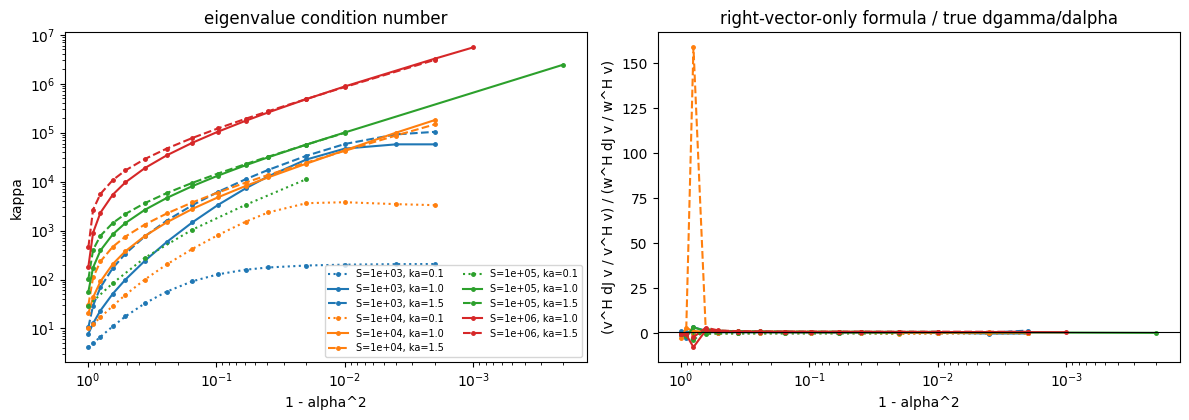

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.3))
for (S, ka), f in sorted(FAM.items()):
    al, _, _, kap = curve(S, ka)
    ls = {U.KA_NONCONST: ":", U.KA_CONST: "-", U.KA_CONST2: "--"}[ka]
    c = f"C{int(np.log10(S)) - 3}"
    axs[0].loglog(1 - al**2, kap, ls, marker="o", ms=2.5, color=c,
                  label=f"S={S:.0e}, ka={ka}")
    nv = np.array([complex(f[1][a]["naive"]).real/complex(f[1][a]["dlam"]).real for a in al])
    axs[1].semilogx(1 - al**2, nv, ls, marker="o", ms=2.5, color=c)
axs[0].set_xlabel("1 - alpha^2"); axs[0].set_ylabel("kappa"); axs[0].invert_xaxis()
axs[0].legend(fontsize=7, ncol=2); axs[0].set_title("eigenvalue condition number")
axs[1].set_xlabel("1 - alpha^2"); axs[1].set_ylabel("(v^H dJ v / v^H v) / (w^H dJ v / w^H v)")
axs[1].invert_xaxis(); axs[1].set_title("right-vector-only formula / true dgamma/dalpha")
axs[1].axhline(1, color="k", lw=0.8)
plt.tight_layout()

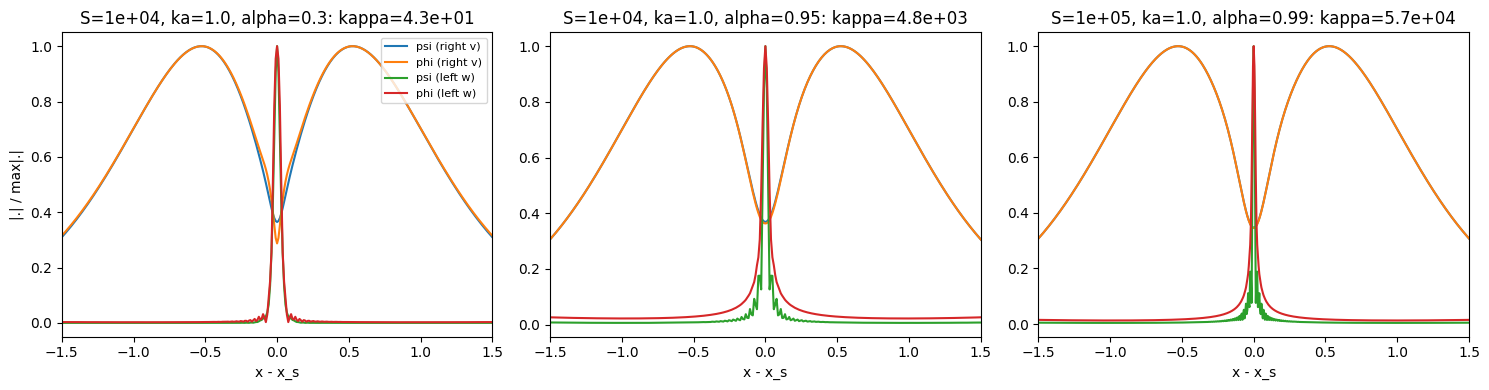

In [14]:
# right vs left eigenvector (psi, phi) near the sheet at one strongly non-normal point
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, (S, ka, a) in zip(axs, ((1e4, 1.0, 0.3), (1e4, 1.0, 0.95), (1e5, 1.0, 0.99))):
    r = FAM[(S, ka)][1][a]
    x = r["xr"]
    for key, lab, c in (("psi_r", "psi (right v)", "C0"), ("phi_r", "phi (right v)", "C1"),
                        ("psi_l", "psi (left w)", "C2"), ("phi_l", "phi (left w)", "C3")):
        y = r[key]; y = y/np.abs(y).max()
        ax.plot(x, np.abs(y), color=c, label=lab)
    ax.set_xlim(-1.5, 1.5); ax.set_xlabel("x - x_s")
    ax.set_title(f"S={S:.0e}, ka={ka}, alpha={a}: kappa={float(r['kappa']):.1e}")
axs[0].set_ylabel("|.| / max|.|"); axs[0].legend(fontsize=8)
plt.tight_layout()

**Result.** (i) **$\kappa$ grows steeply with $\alpha$ and with $S$**: at $ka=1$ from $\approx10$-$10^3$ at
$\alpha=0.3$ to $2\times10^4$-$3\times10^6$ at $\alpha=0.99$-0.9999, rising with $S$ (tables above; values at large $\alpha$ are
*lower bounds*, next item). The shear-flow tearing eigenvalue is strongly non-normal everywhere the
paper's asymptotics live. (ii) **The right-vector-only formula is useless**: for $ka=0.1$, where the true $p$ is 0.43-0.64, it gives
1.5-11 % of the true $d\gamma/d\alpha$ ($p\approx0.01$-0.06) -- and $-16$ %, the **wrong sign**, at $S=10^4$, $\alpha=0.3$; for $ka\ge1$ it
is 0.3-1.3 of it at $\alpha=0.8$-0.99, and at $\alpha=0.3$ (true $p$ from $-1.07$ to $+0.31$) it is off by factors 0.4-3 in
magnitude, with the **wrong sign** for $ka=1.5$ at every $S$ and for $ka=1$ at $S\ge10^5$. The left
vector matters at the 1b gate's own point already (rung 1b machinery: 0.21 off at $\kappa=3.7$). (iii)
**$\kappa$ needs a much finer grid than $\lambda$.** At $S=10^4$, $ka=1$, $\alpha=0.95$, $\gamma$ and
$d\gamma/d\alpha$ agree to $\sim10^{-9}$ from $n_x=512$ to 16384, while $\kappa$ runs
479, 1630, 4760, 10600, 15500, 16400 at $n_x=512$, 1024, ..., 16384 -- converging, but only at $n_x\gtrsim8192$, 8 times finer than the eigenvalue needs (at $\alpha=0.3$
and at $S=10^3$, $\alpha=0.8$ it is converged by $n_x=2048$-4096). The eigenvector figure shows why: the
right vector is the familiar extended tearing mode ($\phi\approx\alpha\psi$ outside the layer, ideal Ohm's
law with the flow), while the **left vector is concentrated in the resistive layer** and carries
grid-scale oscillation there at large $\alpha$ -- the eigenvalue is sensitive to perturbations *inside the
layer*, which is also why $v^H\partial J v$ (weighted by the outer region) gets it wrong. $\partial_\alpha J$ is
smooth, so $w^H\partial_\alpha J v$ converges long before $\|w\|$ does.

**Where the harness refuses.** The isolation test $\kappa\,\delta/\mathrm{gap}\le10^{-3}$ (gap $=\gamma$, the
distance to the null cluster) failed at $S=10^5$, $1-\alpha^2\le4\times10^{-3}$ ($ka=1$: $\alpha=0.998$-0.9998; $ka=1.5$: 0.998-0.9999), at $S=10^6$ on the $n_x^{hi}=16384$ grid for $\alpha=0.998$ ($ka=1$, 1.5) and 0.9998 ($ka=1$), and in several $n_x^{hi}/2$ grid checks ($S=10^5$: $\alpha\ge0.9995$ at $ka=1$, $\ge0.9998$ at 1.5; $S=10^6$: $\alpha=0.99$ at both $ka$, 0.9998 and 0.9999 at $ka=1$). At $S=10^6$, $ka=1$, $\alpha=0.9999$ the right pair itself failed `shift_invert`'s residual gate ($1.5\times10^{-9}$ against $10^{-9}$), and $S=10^6$, $ka=1.5$, $\alpha\ge0.9995$ was not computed. E.g. $S=10^5$, $ka=1$, $\alpha=0.998$: $\kappa=2.1\times10^5$,
backward error $\delta=1.2\times10^{-11}$, gap $4.8\times10^{-4}$, $\kappa\delta/\mathrm{gap}=5\times10^{-3}$. The limit
is the **attainable backward error of the shifted solves**, not the physics: GMRES stalls above its
normal-operator tolerance once $\kappa\gtrsim10^5$ (the solver retries with looser inner tolerances, and
`shift_invert`'s own residual gate still guards every pair), and when a retry happens to land a pair at
round-off the same eigenvalue passes -- $S=10^5$, $ka=1$, $\alpha=0.9999$ at $\kappa=2.4\times10^6$,
$\delta\approx10^{-16}\|J\|$, $\kappa\delta/\mathrm{gap}=3\times10^{-6}$. Nothing was loosened in the harness.

### 5. The marginal point by Newton in the sheet width

Plain Newton on $\gamma(a)=0$ at fixed $k$ and $\eta$, $a\leftarrow a-\gamma/(\partial_a\gamma)$, every iterate
converged in $n_x$ ($\gamma$ and $\partial_a\gamma$ to $10^{-4}$ between rungs, up to $n_x=32768$), from $ka=2$
(sech$^2$, $k=\sqrt5$, $L_x=20$) and $ka=0.8$ (tanh pair, $k=1$, $L_x=30$, **each parity sector
separately**: the pair members are split only by $e^{-kL_x/2}$, far too close for the isolation test on
the full block, and exactly decoupled by the reflection symmetry $f(k_x)\to f(-k_x)$, which commutes with
$J$ to $5\times10^{-14}$; the sensitivity runs on $E^HJE$). The root is $a=1$ in both. The last columns
are the multiplicity estimate $p=1/\mathrm{slope}(\gamma/\gamma')$ from consecutive iterates and the
**multiplicity-corrected** root $a-p\,\gamma/\gamma'$.

In [15]:
MT = {}
for (case, S, sec), (its, why) in MARG.items():
    rows = U.newton_table(its)
    MT[(case, S, sec)] = (rows, why)
    name = {"sech2": "sech^2 (k = sqrt 5)", "tanhpair": f"tanh pair, sector {sec:+d} (k = 1)"}[case]
    print(f"\n{name}, S = {S:.0e}: plain Newton on gamma(a) = 0, root a = 1  (stop: {why})")
    print("  it  a              1 - a      ratio   gamma        dgamma/da     nx     kappa   "
          "rel_err  |  p = 1/slope(g/g')   a - p g/g'     |a* - 1|")
    prev = None
    for i, r in enumerate(rows):
        e = 1 - r["a"]
        ratio = e/prev if prev else np.nan
        prev = e
        print(f"  {i:2d}  {r['a']:.10f}  {e:.3e}  {ratio:5.3f}  {r['gamma']:.4e}  {r['dgamma']:+.4e}  "
              f"{r['nx']:6d}  {r['kappa']:6.1f}  {r['rel_err']:.0e}  |  {r['p']:7.3f}           "
              f"{r['astar']:.8f}   {abs(r['astar'] - 1):.1e}")


sech^2 (k = sqrt 5), S = 1e+03: plain Newton on gamma(a) = 0, root a = 1  (stop: nx cap)
  it  a              1 - a      ratio   gamma        dgamma/da     nx     kappa   rel_err  |  p = 1/slope(g/g')   a - p g/g'     |a* - 1|
   0  0.8944271910  1.056e-01    nan  1.3605e-02  -1.8078e-01    4096    17.7  2e-11  |      nan           nan   nan
   1  0.9696860374  3.031e-02  0.287  1.4423e-03  -1.2227e-01    4096    58.6  6e-07  |    1.186           0.98367506   1.6e-02
   2  0.9814823692  1.852e-02  0.611  3.2000e-04  -6.0503e-02    8192    75.7  2e-06  |    1.813           0.99107011   8.9e-03
   3  0.9867713590  1.323e-02  0.714  9.2294e-05  -2.6808e-02    8192    73.4  7e-06  |    2.865           0.99663459   3.4e-03
   4  0.9902141894  9.786e-03  0.740  2.8410e-05  -1.1482e-02   16384    65.9  7e-06  |    3.555           0.99900997   9.9e-04
   5  0.9926885207  7.311e-03  0.747  8.9156e-06  -4.8656e-03   16384    57.8  1e-06  |    3.854           0.99975139   2.5e-04
   6  0.9945209

In [16]:
# the same Newton on ONE fixed coarse grid (nx = 256, Lx = 20, S = 1e3; dense blocks, ~15 s,
# computed live -- the configuration tests/test_tearing_sensitivity.py pins)
import taranis as jr
from taranis import stability as st
a, rows = 2.0/np.sqrt(5), []
for n in range(8):
    p = U.make_params(1e3, np.sqrt(5), 256, 20.0); kg = jr.setup_kgrids(p)
    x0, dx0 = U.equilibrium(p, 0.0, a, "a")
    B, _ = st.ky_block_matrix(x0, kg, p, 1); r = st.eig_dense(B)
    dB, _ = st.dj_matrix(x0, dx0, kg, p, iky=1)
    s = st.eigenvalue_sensitivity(B, dB, r.values[0], r.right[:, 0], r.left[:, 0], spectrum=r.values)
    rows.append(dict(a=a, gamma=r.values[0].real, dgamma=s.dlam.real, nx=256, rec=dict(kappa=s.kappa,
                                                                                       rel_err=s.rel_err)))
    a = a - r.values[0].real/s.dlam.real
print("  it  ka            1 - a      ratio   gamma       p = 1/slope(g/g')   ka* = k(a - p g/g')   |ka* - sqrt5|")
prev = None
for i, r in enumerate(U.newton_table(rows)):
    e = 1 - r["a"]
    print(f"  {i:2d}  {np.sqrt(5)*r['a']:.8f}  {e:.3e}  {(e/prev if prev else np.nan):5.3f}  {r['gamma']:.3e}   "
          f"{r['p']:7.3f}             {np.sqrt(5)*r['astar']:.8f}          {abs(np.sqrt(5)*(r['astar'] - 1)):.1e}")
    prev = e

  it  ka            1 - a      ratio   gamma       p = 1/slope(g/g')   ka* = k(a - p g/g')   |ka* - sqrt5|
   0  2.00000000  1.056e-01    nan  1.774e-02       nan             nan          nan
   1  2.20005736  1.610e-02  0.153  1.412e-03     1.119             2.22392280          1.2e-02
   2  2.22137925  6.569e-03  0.408  2.686e-04     1.540             2.23289916          3.2e-03
   3  2.22885832  3.224e-03  0.491  6.493e-05     1.920             2.23573902          3.3e-04
   4  2.23244203  1.622e-03  0.503  1.628e-05     2.012             2.23606722          7.6e-07
   5  2.23424420  8.156e-04  0.503  4.092e-06     2.018             2.23607928          1.1e-05
   6  2.23515343  4.090e-04  0.501  1.027e-06     2.011             2.23607241          4.4e-06
   7  2.23561047  2.046e-04  0.500  2.571e-07     2.004             2.23606937          1.4e-06


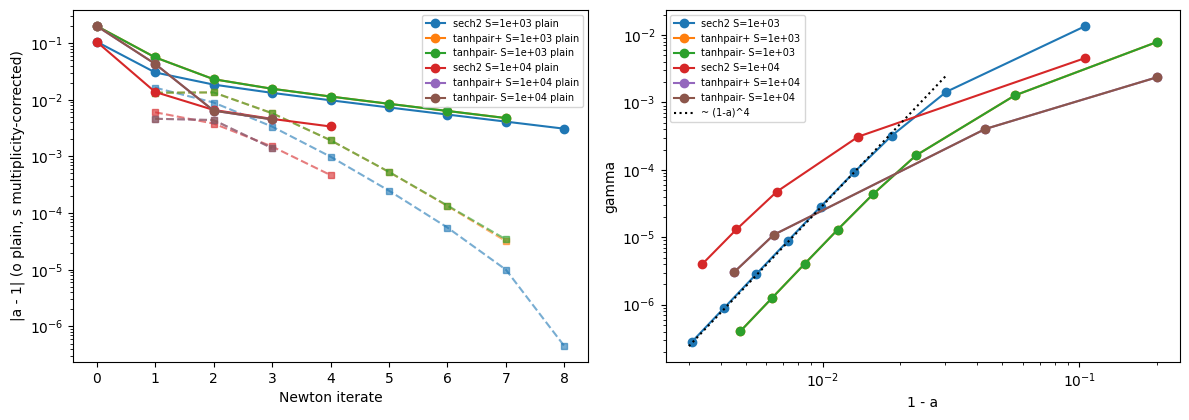

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.3))
for j, ((case, S, sec), (rows, _)) in enumerate(MT.items()):
    lab = f"{case}{'' if not sec else ('+' if sec > 0 else '-')} S={S:.0e}"
    a = np.array([r["a"] for r in rows]); g = np.array([r["gamma"] for r in rows])
    ast = np.array([r["astar"] for r in rows])
    axs[0].semilogy(np.arange(len(a)), 1 - a, "o-", color=f"C{j}", label=lab + " plain")
    axs[0].semilogy(np.arange(len(a)), np.abs(ast - 1), "s--", color=f"C{j}", ms=4, alpha=0.6)
    axs[1].loglog(1 - a, g, "o-", color=f"C{j}", label=lab)
d = np.geomspace(3e-3, 3e-2, 10)
axs[1].loglog(d, 3e3*d**4, "k:", label="~ (1-a)^4")
axs[0].set_xlabel("Newton iterate"); axs[0].set_ylabel("|a - 1| (o plain, s multiplicity-corrected)")
axs[1].set_xlabel("1 - a"); axs[1].set_ylabel("gamma")
axs[0].legend(fontsize=7); axs[1].legend(fontsize=7)
plt.tight_layout()

**Result: Newton lands on the exact marginal point -- but only because the root's multiplicity is
measured; plain Newton converges linearly, never quadratically.**

* **The root is not simple.** Rung 1a found the growth suppressed in a band $\Delta'a\lesssim22S^{-1/2}$
  near marginality with $\gamma\propto S\,\Delta'^4$ there (its $\gamma$ at $ka=2.23$-2.235 scales like
  $S$ and like $(\sqrt5-ka)^4$). Newton on a root of multiplicity $p$ contracts the error by $1-1/p$ per step:
  the measured ratio settles at **0.750** for sech$^2$ and 0.749 for both tanh-pair members at $S=10^3$ (at $S=10^4$ it is
  still rising, 0.734 and 0.699, when the $n_x$ cap stops the runs), and
  $p=1/\mathrm{slope}(\gamma/\gamma')$ converges to **4.00** (3.99-4.00 for sech$^2$ at $S=10^3$, 3.97 for both tanh members; 3.38 and 2.60 when the $n_x$ cap stops the $S=10^4$ runs, still rising). Outside the band (the first steps)
  $\gamma\propto\Delta'^{4/5}$ (FKR, $p<1$) and Newton jumps by more than the distance to the root.
* **Multiplicity-corrected Newton converges fast** (squares in the figure): sech$^2$ $S=10^3$ lands on
  **$\sqrt5$ to a few $\times10^{-6}$** after 9 iterates (the last corrected iterate is $4.5\times10^{-7}$ from it, $ka^*=2.2360670$, but it still
  moves by $\sim10^{-5}$ per step, and a $\gamma$-only three-point fit $\gamma=C(a^*-a)^p$ to the same iterates gives $p=3.999$ and
  $|a^*-1|=3.7\times10^{-6}$: the digits beyond that are estimator-dependent); $S=10^4$ at $a^*=0.99953$ ($p$ still rising, 3.38; the
  $\gamma$-only fit gives 0.99909) after
  5; the tanh pair at $a^*=0.999968$ and 0.999966 ($S=10^3$, both members; the $\gamma$-only fit gives $7\times10^{-5}$ from 1,
  $p=3.94$), i.e. $a^*=1$ to $\lesssim10^{-4}$ -- the two sectors differ by $2.4\times10^{-6}$ in either estimate, $\sim$ the image
  coupling. The zero of $\gamma$ is at $\Delta'=0$ to these digits -- the finite-$S$ physics is the band, not
  a shift of the zero, as rung 1a concluded from its $ka$ scan.
* **On one fixed coarse grid** the discrete root is a *double* root exactly at $\sqrt5$ ($n_x=256$: $p\to2.01$,
  ratio 0.500, $ka^*$ within $4\times10^{-6}$ of $\sqrt5$ -- `tests/test_tearing_sensitivity.py` pins this): the
  multiplicity is a property of the resolved layer, and changes with $n_x$ while the layer is unresolved.
* **What stops it** (measured): the iterates need $n_x=32768$ once $\gamma\lesssim3\times10^{-6}$ (sech$^2$,
  $S=10^3$: $\sqrt5-ka=0.012$; the layer thins as $\gamma^{1/4}$, rung 1a), where the ladder hits its cap;
  sech$^2$ $S=10^3$ iterates 7 and 8 needed the looser-GMRES retries at $n_x=32768$ (rel_err $6$ and $5\times10^{-4}$, just
  inside the $10^{-3}$ refusal). For the tanh pair at $S=10^4$ a single shift at $\gamma\lesssim10^{-5}$ converged onto
  members of the $\nu=0$ null cluster ($|\lambda|\le10^{-12}$) at every retry -- near a defective cluster the
  resolvent is dominated by the cluster -- until the ladder tried 2.5 and 0.4 times the previous rung; it then
  runs 4 iterates to the $n_x$ cap ($\kappa\approx630$ there). $\kappa$ itself stays moderate (15-630) along every Newton path: near marginality the
  eigenvalue is ill-*isolated* (gap $=\gamma\to0$), not ill-conditioned.

### 6. Summary

* **The sensitivity machinery is right.** $w^H\partial_\alpha J\,v/w^Hv$ against central differences of
  eigenvalues converges at $O(h^2)$ (orders 1.83-2.007) at four points up to $S=10^5$, $\alpha=0.99$;
  $d\gamma/d\alpha$ is grid-converged to $\sim10^{-9}$ by $n_x=512$-2048 where $\gamma$ is. One sensitivity
  per point turns the paper's fitted slopes into curves.
* **Running exponents** $p=d\ln\gamma/d\ln(1-\alpha^2)$: constant-$\psi$ ($ka=1$, 1.5) **reaches 1/2**
  (0.496 at $S=10^6$, $1-\alpha^2=0.01$, $ka=1$), approached from below as $\alpha\to1$, from above as $S$
  grows at fixed $\alpha$; nonconstant-$\psi$ ($ka=0.1$) plateaus at 0.51, 0.61, **0.646** for
  $S=10^3,10^4,10^5$ -- rising toward 2/3, 3 % short at $S=10^5$ (that family not grid-checked in $n_x$). Where the data reach
  far enough the curves then bend away (a peak at 0.566-0.578 for constant-$\psi$ at $\delta_{in}/a\approx0.17$-0.22, $S\le10^4$;
  a fall toward $p\approx0$ for both) once the shear layer
  $\delta_{in}/a=(\alpha/(1-\alpha^2))^{1/3}(kaS)^{-1/3}$ exceeds $\approx0.1$-0.2; at $S\ge10^5$ the constant-$\psi$ curves are
  cut by refusals before a peak (the one $S=10^5$ point beyond, at $\delta_{in}/a=0.37$, is down to 0.29 like $S=10^3$, $10^4$): the
  asymptotic window is $\delta_{in}\lesssim0.1a$, and only opens at $S\gtrsim10^5$.
* **Ridge:** $p_{ridge}$ crosses $4/7$ at $1-\alpha^2\approx0.25$ ($S=10^4$) / 0.14 ($S=10^5$) and peaks at 0.591 ($S=10^4$, $1-\alpha^2=0.04$) / 0.593 ($S=10^5$, $1-\alpha^2=0.01$, still rising slowly), decreasing with $S$ at
  fixed $\alpha$ -- consistent with $4/7$ from above, not reached at $S=10^5$. $d\ln k_{max}/d\ln(1-\alpha^2)$ runs
  through $-1/7$ at $1-\alpha^2\approx0.25$ ($S=10^4$) / 0.14 ($S=10^5$, then within 5 % of it down to 0.04). Integrated, it reproduces 1b-ref's
  $\gamma_{max}(\alpha)/\gamma_{max}(0)$ (0.955, 0.80, 0.58, 0.27-0.28) to $\le3\times10^{-3}$; the secant exponent
  0.55 behind "a few % above $(1-\alpha^2)^{4/7}$" is the average of a running exponent that crosses 4/7.
* **Marginal Newton** in the sheet width (family $\Psi_0=a\hat\Psi_0(x/a)$, $\Delta'a=F(ka)$): plain Newton is
  **linear** with ratio **0.750**, because the root has multiplicity $p=4.00$ -- rung 1a's suppression band,
  $\gamma\propto S\Delta'^4$; with the measured multiplicity it lands on **$\sqrt5$ to a few $\times10^{-6}$**
  ($S=10^3$; further digits depend on the estimator), on 0.99953 ($S=10^4$, $p$ not converged), and on $a^*=1$ to $\lesssim10^{-4}$
  for both tanh-pair members (parity sectors). Not
  quadratic, and it should not be: the zero of $\gamma$ is non-analytic in $\Delta'$.
* **Non-normality:** $\kappa$ from $\sim10$ to $>10^6$ as $\alpha\to1$ and $S$ grows. The right-vector-only
  formula is wrong by factors 9-70 ($ka=0.1$, and in sign at $S=10^4$, $\alpha=0.3$) and in sign at $\alpha=0.3$ for $ka=1.5$
  and for $ka=1$ at $S\ge10^5$. The left vector lives in
  the resistive layer; $\kappa$ converges only at $\sim8\times$ the $n_x$ the eigenvalue needs.

**Measured method limits.**
* The harness refuses (isolation, $\kappa\delta/\mathrm{gap}>10^{-3}$, gap $=\gamma$ to the $\nu=0$ null cluster)
  where the shifted GMRES solves stall at a backward error $\delta\sim10^{-11}$ with $\kappa\gtrsim10^5$:
  $ka\ge1$ at $1-\alpha^2\lesssim4\times10^{-3}$ for $S=10^5$, at $\alpha=0.998$ (both $ka$) and 0.9998 ($ka=1$) for $S=10^6$, and in
  several $n_x^{hi}/2$ grid checks; one $S=10^6$ pair ($ka=1$, $\alpha=0.9999$) failed `shift_invert`'s residual gate instead,
  and $S=10^6$, $ka=1.5$, $\alpha\ge0.9995$ was not computed. A
  round-off pair passes at $\kappa=2.4\times10^6$; the limit is the inner solver, not the formula.
* `shift_invert` with $k\ge2$ never converges next to the null cluster (the gap comes from a coarse dense
  spectrum instead), and near a defective cluster a shift a few $\gamma$ away can converge onto cluster
  members ($|\lambda|\le10^{-12}$): the marginal ladders try 1, 2.5 and 0.4 times the previous rung.
* Marginal Newton stops at the $n_x=32768$ cap once $\gamma\lesssim3\times10^{-7}$ ($S=10^3$) /
  $4\times10^{-6}$ ($S=10^4$); the layer thins as $\gamma^{1/4}$.
* $ka=0.1$ at $S=10^5$ ($L_x=150$, $n_x=8192$) costs 10-15 min per point on this laptop (the band LU);
  the family stops at $\alpha=0.99$ (0.995 and 0.998 dropped after 4 and 2 GMRES-stalled shifts, for time) and has six
  $\alpha$, with an $n_x^{hi}/2$ check at $\alpha=0.1$ only.
* FD steps near $\alpha=1$ must satisfy $h\ll1-\alpha$ ($h=0.01$ at $\alpha=0.99$ is off by 98 %).

In [18]:
paths = glob.glob(os.path.join(U.DATA_ROOT, "solves", "*.npz"))
recs = [np.load(p) for p in paths]
secs = np.array([float(r["seconds"]) for r in recs if "seconds" in r.files])
nxs = np.array([int(r["nx"]) for r in recs if "nx" in r.files])
size = sum(os.path.getsize(p) for p in paths)
nfail = len(glob.glob(os.path.join(U.DATA_ROOT, "solves", "*.failed")))
print(f"{len(recs)} cached solves ({nfail} cached failures, retried at moved shifts), "
      f"{secs.sum()/3600:.2f} h of sensitivity-solve time (the FD eigen-solves are not timed), "
      f"{size/2**20:.1f} MiB; largest nx = {nxs.max()}, "
      f"slowest solve {secs.max():.0f} s; this execution {time.time() - t0:.0f} s")

589 cached solves (339 cached failures, retried at moved shifts), 5.58 h of sensitivity-solve time (the FD eigen-solves are not timed), 42.8 MiB; largest nx = 32768, slowest solve 869 s; this execution 9 s
